# LibreProject/MS Project XML Prototype

This notebook uses the separate interface layer to load a planning-file network into the mathematical simulator. The prototype convention is: scheduled duration is the smallest mode, and task notes contain `Min: a_i`.

In [1]:
from pathlib import Path
import sys
import time

import matplotlib.pyplot as plt
import numpy as np

cwd = Path.cwd().resolve()
repo_root = next(path for path in [cwd, *cwd.parents] if (path / "src" / "spm").exists())
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from spm.interfaces import draw_project_network, load_project_from_xml, print_project_diagnostics


In [2]:
file_path = repo_root / "Example project" / "Building Garage.xml"
imported = load_project_from_xml(file_path, sample_count=10**4, rng_seed=1)

imported.name, len(imported.tasks), imported.simulator_project.topological_order()

('Building Garage', 11, [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])

<Axes: title={'center': 'Building Garage'}>

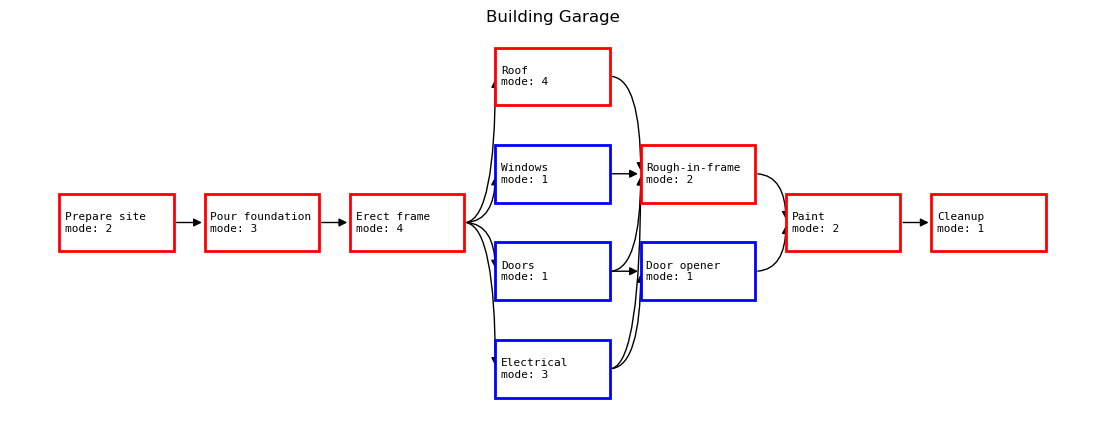

In [3]:
draw_project_network(imported)

In [4]:
print_project_diagnostics(imported)

Project: Building Garage

id | task | predecessors | distribution | a_i | lambda_i | modes | E[D_i]
----------------------------------------------------------------------------------------
1 | Prepare site | empty | ShiftedPoi(lambda=2, a=1) | 1 | 2 | 2, 3 | 3
2 | Pour foundation | 1 | ShiftedPoi(lambda=3, a=1) | 1 | 3 | 3, 4 | 4
3 | Erect frame | 2 | ShiftedPoi(lambda=3, a=2) | 2 | 3 | 4, 5 | 5
4 | Roof | 3 | ShiftedPoi(lambda=4, a=1) | 1 | 4 | 4, 5 | 5
5 | Windows | 3 | ShiftedPoi(lambda=1, a=1) | 1 | 1 | 1, 2 | 2
6 | Doors | 3 | ShiftedPoi(lambda=1, a=1) | 1 | 1 | 1, 2 | 2
7 | Electrical | 3 | ShiftedPoi(lambda=3, a=1) | 1 | 3 | 3, 4 | 4
8 | Rough-in-frame | 4, 5, 6, 7 | ShiftedPoi(lambda=2, a=1) | 1 | 2 | 2, 3 | 3
9 | Door opener | 6, 7 | ShiftedPoi(lambda=1, a=1) | 1 | 1 | 1, 2 | 2
10 | Paint | 8, 9 | ShiftedPoi(lambda=2, a=1) | 1 | 2 | 2, 3 | 3
11 | Cleanup | 10 | ShiftedPoi(lambda=1, a=1) | 1 | 1 | 1, 2 | 2


## Exact CDF versus Monte Carlo

This is deliberately a notebook-only prototype diagnostic. It compares the exact grouped shifted-Poisson CDF against direct Monte Carlo simulation. The expensive experiment cells save their arrays and runtimes to `notebooks/_experiment_cache`, so diagnostics and plots can be rerun without recomputing the exact CDF or the Monte Carlo sample. Set the force flags below to `True` when you intentionally want a fresh run.


In [5]:
MAX_T = 20
FORCE_RECOMPUTE_EXACT_CDF = False
CDF_NUMERIC_VERSION = "support_longdouble_v2"
EPS = 1e-12
SAMPLE_COUNT_FOR_COMPARISON = 1_000_000_000
RNG_SEED_FOR_COMPARISON = 2026
FORCE_RECOMPUTE_MONTE_CARLO = False

target_support = np.arange(MAX_T + 1, dtype=np.int64)
comparison_project = load_project_from_xml(
    file_path,
    sample_count=SAMPLE_COUNT_FOR_COMPARISON,
    rng_seed=RNG_SEED_FOR_COMPARISON,
).simulator_project

cache_dir = repo_root / "notebooks" / "_experiment_cache"
cache_dir.mkdir(parents=True, exist_ok=True)
file_label = file_path.stem.replace(" ", "_").replace(".", "_")
file_signature = file_path.stat().st_mtime_ns
experiment_label = f"{file_label}_sig_{file_signature}"
exact_cache_path = cache_dir / f"{experiment_label}_exact_cdf_growing_{CDF_NUMERIC_VERSION}.npz"
monte_carlo_cache_path = cache_dir / (
    f"{experiment_label}_samples_{SAMPLE_COUNT_FOR_COMPARISON}_seed_{RNG_SEED_FOR_COMPARISON}_monte_carlo.npz"
)

print(f"Exact CDF target after initial cell: t = 0, ..., {MAX_T}")
print(f"Monte Carlo sample count: {SAMPLE_COUNT_FOR_COMPARISON:,}")
print(f"Exact CDF numeric version: {CDF_NUMERIC_VERSION}")
print(f"Exact CDF growing cache: {exact_cache_path}")
print(f"Monte Carlo sample cache: {monte_carlo_cache_path}")


Exact CDF target after initial cell: t = 0, ..., 20
Monte Carlo sample count: 1,000,000,000
Exact CDF numeric version: support_longdouble_v2
Exact CDF growing cache: C:\Users\johan\OneDrive\Skrivbord\SPM\notebooks\_experiment_cache\Building_Garage_sig_1779049297916769800_exact_cdf_growing_support_longdouble_v2.npz
Monte Carlo sample cache: C:\Users\johan\OneDrive\Skrivbord\SPM\notebooks\_experiment_cache\Building_Garage_sig_1779049297916769800_samples_1000000000_seed_2026_monte_carlo.npz


In [6]:
def save_exact_cdf_cache():
    """Save the currently computed exact CDF grid and per-threshold runtimes."""
    np.savez_compressed(
        exact_cache_path,
        support=support,
        exact_cdf=exact_cdf,
        exact_pmf=exact_pmf,
        exact_tail_mass=np.asarray(exact_tail_mass),
        exact_runtime_total_seconds=np.asarray(exact_runtime),
        exact_cdf_runtime_by_t_seconds=exact_cdf_runtime_by_t,
        exact_cdf_runtime_table=exact_cdf_runtime_table,
        max_t=np.asarray(int(support[-1])),
    )


def refresh_exact_cdf_derived_values():
    """Recompute PMF, tail mass, and the printed runtime table from the CDF grid."""
    global MAX_T, exact_pmf, exact_tail_mass, exact_cdf_runtime_table
    if len(support) != len(exact_cdf) or len(support) != len(exact_cdf_runtime_by_t):
        raise ValueError(
            "exact CDF arrays must have matching lengths: "
            f"support={len(support)}, cdf={len(exact_cdf)}, runtimes={len(exact_cdf_runtime_by_t)}"
        )
    if len(support) == 0:
        MAX_T = -1
        exact_pmf = np.asarray([], dtype=np.longdouble)
        exact_tail_mass = 1.0
        exact_cdf_runtime_table = np.empty((0, 3), dtype=np.longdouble)
        return
    MAX_T = int(support[-1])
    exact_pmf = np.diff(np.concatenate(([0.0], exact_cdf)))
    exact_tail_mass = 1.0 - exact_cdf[-1]
    exact_cdf_runtime_table = np.column_stack((support, exact_cdf, exact_cdf_runtime_by_t))


def repair_partial_exact_cdf_state_if_needed():
    """Repair notebook state after interrupted or partially rerun exact-CDF cells."""
    global support
    if "support" not in globals():
        support = np.arange(len(exact_cdf), dtype=np.int64)
        print("Reconstructed missing exact CDF support from the CDF array length.")
    else:
        support = np.asarray(support, dtype=np.int64)

    if len(exact_cdf) != len(exact_cdf_runtime_by_t):
        raise ValueError(
            "exact CDF and runtime arrays must have matching lengths: "
            f"cdf={len(exact_cdf)}, runtimes={len(exact_cdf_runtime_by_t)}"
        )

    if len(support) == len(exact_cdf) + 1 and support[0] == -1:
        support = support[1:]
        print("Repaired previous partial exact CDF state by removing the old -1 sentinel.")

    if len(support) != len(exact_cdf) and len(exact_cdf) == len(exact_cdf_runtime_by_t):
        support = np.arange(len(exact_cdf), dtype=np.int64)
        print(
            "Reconstructed exact CDF support as 0, ..., "
            f"{int(support[-1])} from the saved CDF/runtime array lengths."
        )


def print_exact_cdf_summary():
    """Print diagnostics for the cached exact CDF experiment."""
    if len(support) == 0:
        print("Exact CDF cache is empty.")
        return
    print(f"Exact CDF currently covers t = 0, ..., {int(support[-1])}")
    print(f"Exact CDF total runtime: {exact_runtime:.2f} seconds")
    print(f"Slowest single CDF evaluation: {exact_cdf_runtime_by_t.max():.4f} seconds")
    print(f"CDF monotone: {bool(np.all(np.diff(exact_cdf) >= -EPS))}")
    print(f"Mass on 0..{MAX_T}: {exact_pmf.sum():.8f}")
    print(f"Tail mass above {MAX_T}: {exact_tail_mass:.8f}")
    print("\nPer-t exact CDF runtimes:")
    print("t | F_T(t) | seconds")
    print("-" * 34)
    for t, cdf_at_t, runtime_at_t in exact_cdf_runtime_table:
        print(f"{int(t):3d} | {cdf_at_t:.10f} | {runtime_at_t:.4f}")


def compute_and_append_exact_cdf(end_t):
    """Append exact CDF values from the next missing integer t through end_t."""
    global support, exact_cdf, exact_runtime, exact_cdf_runtime_by_t
    start_t = 0 if len(support) == 0 else int(support[-1]) + 1
    end_t = int(end_t)
    if end_t < start_t:
        current_end = "empty" if len(support) == 0 else f"0, ..., {int(support[-1])}"
        print(f"Exact CDF cache already covers t = {current_end}.")
        return

    new_support = np.arange(start_t, end_t + 1, dtype=np.int64)
    new_cdf_values = []
    new_runtimes = np.zeros_like(new_support, dtype=float)
    extension_start_time = time.perf_counter()

    for index, t in enumerate(new_support):
        # Per-threshold timing: start just before F_T(t), stop just after that call returns.
        run_start_time = time.perf_counter()
        cdf_at_t = comparison_project.project_completion_cdf_shifted_poisson(int(t))
        new_runtimes[index] = time.perf_counter() - run_start_time
        new_cdf_values.append(cdf_at_t)
        print(
            f"t = {int(t):3d} | "
            f"F_T(t) = {cdf_at_t:.10f} | "
            f"runtime = {new_runtimes[index]:.4f} seconds"
        )

    support = np.concatenate((support, new_support))
    exact_cdf = np.concatenate((exact_cdf, np.asarray(new_cdf_values, dtype=np.longdouble)))
    exact_cdf_runtime_by_t = np.concatenate((exact_cdf_runtime_by_t, new_runtimes))
    exact_runtime += time.perf_counter() - extension_start_time
    refresh_exact_cdf_derived_values()
    save_exact_cdf_cache()
    print(f"Saved extended exact CDF cache: {exact_cache_path}")


if exact_cache_path.exists() and not FORCE_RECOMPUTE_EXACT_CDF:
    with np.load(exact_cache_path) as cached:
        support = cached["support"].astype(np.int64)
        exact_cdf = cached["exact_cdf"].astype(np.longdouble)
        exact_runtime = float(cached["exact_runtime_total_seconds"])
        exact_cdf_runtime_by_t = cached["exact_cdf_runtime_by_t_seconds"].astype(float)
    repair_partial_exact_cdf_state_if_needed()
    refresh_exact_cdf_derived_values()
    print(f"Loaded exact CDF experiment from cache: {exact_cache_path}")
else:
    previous_state_can_be_recovered = (
        "exact_cdf" in globals()
        and "exact_cdf_runtime_by_t" in globals()
        and len(exact_cdf) > 0
    )
    if previous_state_can_be_recovered and not FORCE_RECOMPUTE_EXACT_CDF:
        support = np.asarray(support, dtype=np.int64)
        exact_cdf = np.asarray(exact_cdf, dtype=np.longdouble)
        exact_cdf_runtime_by_t = np.asarray(exact_cdf_runtime_by_t, dtype=float)
        exact_runtime = float(globals().get("exact_runtime", exact_cdf_runtime_by_t.sum()))
        repair_partial_exact_cdf_state_if_needed()
        refresh_exact_cdf_derived_values()
        save_exact_cdf_cache()
        print(f"Recovered and saved partial exact CDF state: {exact_cache_path}")
    else:
        support = np.asarray([], dtype=np.int64)
        exact_cdf = np.asarray([], dtype=np.longdouble)
        exact_runtime = 0.0
        exact_cdf_runtime_by_t = np.asarray([], dtype=float)

compute_and_append_exact_cdf(MAX_T)
print_exact_cdf_summary()


t =   0 | F_T(t) = 0.0000000000 | runtime = 0.0026 seconds
t =   1 | F_T(t) = 0.0000000000 | runtime = 0.0006 seconds
t =   2 | F_T(t) = 0.0000000000 | runtime = 0.0004 seconds
t =   3 | F_T(t) = 0.0000000000 | runtime = 0.0005 seconds
t =   4 | F_T(t) = 0.0000000000 | runtime = 0.0005 seconds
t =   5 | F_T(t) = 0.0000000000 | runtime = 0.0004 seconds
t =   6 | F_T(t) = 0.0000000000 | runtime = 0.0003 seconds
t =   7 | F_T(t) = 0.0000000000 | runtime = 0.0003 seconds
t =   8 | F_T(t) = 0.0000000001 | runtime = 0.0006 seconds
t =   9 | F_T(t) = 0.0000000108 | runtime = 0.0027 seconds
t =  10 | F_T(t) = 0.0000002459 | runtime = 0.0170 seconds
t =  11 | F_T(t) = 0.0000028181 | runtime = 0.0675 seconds
t =  12 | F_T(t) = 0.0000207637 | runtime = 0.2293 seconds
t =  13 | F_T(t) = 0.0001109429 | runtime = 0.5923 seconds
t =  14 | F_T(t) = 0.0004615525 | runtime = 1.4164 seconds
t =  15 | F_T(t) = 0.0015668865 | runtime = 2.6675 seconds
t =  16 | F_T(t) = 0.0044874290 | runtime = 5.0185 secon

KeyboardInterrupt: 

In [ ]:
# Set EXACT_CDF_EXTRA_RUNS above, then rerun this cell to append more thresholds.
# Example: if the cache currently ends at t=40 and this is 10, it computes t=31, ..., 40.
EXACT_CDF_EXTRA_RUNS = 10  # Run the extension cell after changing this to add more t-values.
if EXACT_CDF_EXTRA_RUNS > 0:
    new_end_t = int(support[-1]) + int(EXACT_CDF_EXTRA_RUNS)
    compute_and_append_exact_cdf(new_end_t)
else:
    print("No extra exact CDF thresholds requested. Set EXACT_CDF_EXTRA_RUNS > 0 to append more.")

print_exact_cdf_summary()


t =  21 | F_T(t) = 0.1373277266 | runtime = 69.1683 seconds
t =  22 | F_T(t) = 0.2072187407 | runtime = 97.2671 seconds
t =  23 | F_T(t) = 0.2921792596 | runtime = 124.1840 seconds
t =  24 | F_T(t) = 0.3879940165 | runtime = 194.7187 seconds
t =  25 | F_T(t) = 0.4887722888 | runtime = 305.1841 seconds


KeyboardInterrupt: 

In [ ]:
current_max_t = int(support[-1])
SAMPLE_COUNT_FOR_COMPARISON = 1_000_000_000
RNG_SEED_FOR_COMPARISON = 2026
FORCE_RECOMPUTE_MONTE_CARLO = False
if monte_carlo_cache_path.exists() and not FORCE_RECOMPUTE_MONTE_CARLO:
    with np.load(monte_carlo_cache_path) as cached:
        samples = cached["completion_samples"].astype(np.int64)
        sample_count = int(cached["sample_count"])
        sample_runtime = float(cached["monte_carlo_runtime_total_seconds"])
    print(f"Loaded Monte Carlo samples from cache: {monte_carlo_cache_path}")
else:
    sample_start_time = time.perf_counter()
    sample_result = comparison_project.simulate_project_time()
    sample_runtime = time.perf_counter() - sample_start_time
    samples = sample_result.completion_times.astype(np.int64)
    sample_count = len(samples)
    np.savez_compressed(
        monte_carlo_cache_path,
        completion_samples=samples.astype(np.uint32, copy=False),
        sample_count=np.asarray(sample_count),
        monte_carlo_runtime_total_seconds=np.asarray(sample_runtime),
        rng_seed=np.asarray(RNG_SEED_FOR_COMPARISON),
    )
    print(f"Saved Monte Carlo samples to cache: {monte_carlo_cache_path}")

# Re-bin from raw samples every time, so extending the exact CDF grid keeps diagnostics aligned.
sample_bins = np.bincount(np.minimum(samples, current_max_t + 1), minlength=current_max_t + 2)
empirical_pmf = sample_bins[: current_max_t + 1] / sample_count
empirical_tail_mass = sample_bins[current_max_t + 1] / sample_count
empirical_cdf = np.cumsum(empirical_pmf)

print(f"Monte Carlo runtime: {sample_runtime:.2f} seconds")
print(f"Monte Carlo sample count: {sample_count:,}")
print(f"Monte Carlo bins now use t = 0, ..., {current_max_t}")
print(f"Sample mean from raw simulated completion times: {samples.mean():.6f}")
print(f"Sample variance from raw simulated completion times: {samples.var(ddof=1):.6f}")
print(f"Empirical mass on 0..{current_max_t}: {empirical_pmf.sum():.8f}")
print(f"Empirical tail mass above {current_max_t}: {empirical_tail_mass:.8f}")


In [ ]:
def distribution_with_tail(pmf, tail_mass):
    """Append P(T_project > MAX_T) as one shared diagnostic tail bin."""
    values = np.concatenate((pmf, [tail_mass]))
    values = np.maximum(values, 0.0)
    return values / np.maximum(values.sum(), EPS)


def kl_divergence(p, q):
    """Compute KL(p || q) on the shared binned support with small smoothing."""
    p_smooth = np.maximum(p, EPS)
    q_smooth = np.maximum(q, EPS)
    p_smooth = p_smooth / p_smooth.sum()
    q_smooth = q_smooth / q_smooth.sum()
    return float(np.sum(p_smooth * np.log(p_smooth / q_smooth)))


def quantile_from_cdf(cdf, probability):
    """Return the smallest integer t such that F(t) >= probability."""
    index = int(np.searchsorted(cdf, probability, side="left"))
    return index if index <= MAX_T else None


exact_distribution = distribution_with_tail(exact_pmf, exact_tail_mass)
empirical_distribution = distribution_with_tail(empirical_pmf, empirical_tail_mass)
mid_distribution = 0.5 * (exact_distribution + empirical_distribution)
binned_support = np.arange(MAX_T + 2, dtype=np.int64)

exact_binned_mean = float(np.sum(binned_support * exact_distribution))
empirical_binned_mean = float(np.sum(binned_support * empirical_distribution))
exact_binned_variance = float(np.sum((binned_support - exact_binned_mean) ** 2 * exact_distribution))
empirical_binned_variance = float(np.sum((binned_support - empirical_binned_mean) ** 2 * empirical_distribution))
truncated_exact_mean = float(np.sum(support * exact_pmf))
truncated_empirical_mean = float(np.sum(support * empirical_pmf))

diagnostics = {
    "exact_runtime_total_seconds": exact_runtime,
    "exact_runtime_mean_per_t_seconds": float(exact_cdf_runtime_by_t.mean()),
    "exact_runtime_max_per_t_seconds": float(exact_cdf_runtime_by_t.max()),
    "monte_carlo_runtime_total_seconds": sample_runtime,
    "monte_carlo_sample_count": sample_count,
    "exact_tail_mass": exact_tail_mass,
    "empirical_tail_mass": empirical_tail_mass,
    "binned_exact_mean_tail_at_MAX_T_plus_1": exact_binned_mean,
    "binned_empirical_mean_tail_at_MAX_T_plus_1": empirical_binned_mean,
    "raw_monte_carlo_mean": float(samples.mean()),
    "binned_exact_variance_tail_at_MAX_T_plus_1": exact_binned_variance,
    "binned_empirical_variance_tail_at_MAX_T_plus_1": empirical_binned_variance,
    "raw_monte_carlo_variance": float(samples.var(ddof=1)),
    "truncated_exact_mean_0_to_MAX_T": truncated_exact_mean,
    "truncated_empirical_mean_0_to_MAX_T": truncated_empirical_mean,
    "cdf_mean_absolute_error": float(np.mean(np.abs(empirical_cdf - exact_cdf))),
    "cdf_rmse": float(np.sqrt(np.mean((empirical_cdf - exact_cdf) ** 2))),
    "kolmogorov_smirnov_distance": float(np.max(np.abs(empirical_cdf - exact_cdf))),
    "total_variation_distance_with_tail_bin": 0.5 * float(np.sum(np.abs(empirical_distribution - exact_distribution))),
    "kl_exact_to_empirical_with_tail_bin": kl_divergence(exact_distribution, empirical_distribution),
    "kl_empirical_to_exact_with_tail_bin": kl_divergence(empirical_distribution, exact_distribution),
    "jensen_shannon_divergence_with_tail_bin": 0.5 * kl_divergence(exact_distribution, mid_distribution)
    + 0.5 * kl_divergence(empirical_distribution, mid_distribution),
    "exact_q50": quantile_from_cdf(exact_cdf, 0.50),
    "empirical_q50": quantile_from_cdf(empirical_cdf, 0.50),
    "exact_q90": quantile_from_cdf(exact_cdf, 0.90),
    "empirical_q90": quantile_from_cdf(empirical_cdf, 0.90),
    "exact_q95": quantile_from_cdf(exact_cdf, 0.95),
    "empirical_q95": quantile_from_cdf(empirical_cdf, 0.95),
}

for name, value in diagnostics.items():
    if isinstance(value, float):
        print(f"{name}: {value:.8f}")
    else:
        print(f"{name}: {value}")


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].step(support, exact_cdf, where="post", label="Exact grouped CDF", linewidth=2)
axes[0].step(support, empirical_cdf, where="post", label="Monte Carlo empirical CDF", alpha=0.8)
axes[0].set_title("Completion-time CDF")
axes[0].set_xlabel("t")
axes[0].set_ylabel("P(T_project <= t)")
axes[0].legend()

axes[1].step(support, exact_pmf, where="mid", label="Exact PMF", linewidth=2)
axes[1].step(support, empirical_pmf, where="mid", label="Monte Carlo PMF", alpha=0.8)
axes[1].set_title("Binned probability mass")
axes[1].set_xlabel("t")
axes[1].set_ylabel("Probability")
axes[1].legend()

axes[2].axhline(0.0, color="black", linewidth=1)
axes[2].step(support, empirical_cdf - exact_cdf, where="post", color="tab:red")
axes[2].set_title("Empirical CDF - exact CDF")
axes[2].set_xlabel("t")
axes[2].set_ylabel("Difference")

fig.tight_layout()


In [48]:
result = imported.simulator_project.simulate_project_time()
result.completion_times[:10], result.critical_paths[:3]

(array([23, 26, 31, 20, 24, 23, 29, 26, 30, 20], dtype=uint32),
 [[1, 2, 3, 4, 8, 10, 11], [1, 2, 3, 4, 8, 10, 11], [1, 2, 3, 7, 8, 10, 11]])